# 02 · 읽기 크기와 SSD latency

이 실험은 연속해서 읽는 데이터 크기를 바꾸며 latency 곡선을 직접 측정한다. 크기는 KiB로 표시하고 CSV에는 byte와 bit 수도 저장한다. `1 KiB = 1024 bytes = 8192 bits`다.

## 실행 준비

결과는 `runs/02_chunk_latency/`에 저장합니다. 이 셀을 다시 실행하면 해당 폴더의 이전 결과를 지우고 새로 만듭니다.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tempfile import gettempdir

ROOT = Path.cwd()
if (ROOT / "conclusion/python").is_dir():
    ROOT = ROOT / "conclusion/python"
sys.path.insert(0, str(ROOT))
from reporting import begin, figure, finish
SEED = 0
RUN = begin(ROOT, "02_chunk_latency", SEED)
SUBMODULE = ROOT.parents[1] / "preliminary_research/vlm-flash"
sys.path.insert(0, str(SUBMODULE / "src"))
sys.path.insert(0, str(SUBMODULE / "scripts"))
os.environ.setdefault("TORCH_EXTENSIONS_DIR", str(Path(gettempdir()) / "vlmflash-torch-extensions"))
import profile_flash as profiler
from _lock import exclusive

# No buffered-I/O measurements may enter this notebook's curve.
class DirectOnly:
    def __init__(self, extension):
        self.extension = extension
    def read_rows(self, *args, **kwargs):
        result = self.extension.read_rows(*args, **kwargs)
        if not result[3]:
            raise RuntimeError("Native reader did not use O_DIRECT")
        return result

extension = profiler.native()
if extension is None:
    raise RuntimeError(profiler.unavailable_reason())
reader = DirectOnly(extension)


**결과:** `runs/02_chunk_latency/` · seed `0`

## 측정 방법

`preliminary_research/vlm-flash/scripts/profile_flash.py`의 `prepare_blob`, `measure`, `saturation_throughput`을 그대로 호출한다. 해당 서브모듈의 native C++ `O_DIRECT` reader를 사용한다. 기존 실험의 결과 파일은 입력하지 않는다.

- 크기: 1–256 KiB는 1 KiB 간격, 260–768 KiB는 4 KiB 간격, 총 384개.
- 각 크기에서 chunk 수: `1, 2, 4, 8, 16, 28, 32, 48, 64, 96, 128, 192, 256, 384, 512`. 128 MiB 파일에 들어가는 조합만 측정한다.
- chunk 사이에는 32 KiB 간격을 둔다. CPU reader thread 6개, 각 조합마다 warmup 3회와 측정 10회.
- 같은 크기들을 오름차순·내림차순으로 각각 측정한다. 두 곡선을 모두 보존해 순서에 따른 차이를 확인한다.
- native reader의 요청 분할 한도가 768 KiB이므로 이번 sweep도 그 크기까지다. 작은 요청의 물리 I/O에는 alignment padding이 포함될 수 있다. 크기와 처리량의 분자는 논리적으로 요청한 byte다.

매 실행에서 새 난수 파일을 만들고 preallocation과 fsync를 수행한다. 공용 benchmark lock을 잡고 측정하며, `O_DIRECT`를 쓰지 못하면 중단한다. 임시 파일은 측정 후 삭제한다. 장치 mount와 측정 설정을 기록한다.

## latency의 정의

크기가 $b$ KiB이고 chunk 수가 $q$인 배치의 native I/O 시간 중앙값을 $t_{b,q}$ µs라고 하면 논리 처리량은

$$B(b,q)=\frac{qb/1024}{t_{b,q}/10^6}\quad[\mathrm{MiB/s}].$$

서브모듈은 총 읽기량에 따른 처리량의 3점 이동평균 기울기가 작아지는 구간을 찾고 그 이후 처리량을 평균한다. 그 지점을 찾지 못하면 마지막 20% 점의 처리량을 평균하며, 점이 3개 미만이면 마지막 값을 사용한다. 따라서 출력은 이 절차에 따른 처리량 추정값이며 포화의 증명은 아니다. 각 크기의 배치별 처리량과 마지막 두 배치의 차이를 함께 보존한다.

그 추정값 $\widehat B(b)$를 사용해

$$\widehat L(b)=\frac{b/1024}{\widehat B(b)}\,1000\quad[\mathrm{ms}]$$

로 크기별 latency를 계산한다. 이는 여러 chunk의 처리량에서 환산한 비용이다. 단일 read의 응답 시간이나 모델 전체 실행 시간이 아니다. 환산 전의 배치 시간도 `io_raw.csv`에 모두 남긴다.

In [2]:
SIZES_KIB = np.r_[np.arange(1, 257), np.arange(260, 769, 4)].tolist()
ITERS, WARMUP, THREADS, BLOB_MIB = 10, 3, 6, 128
num_rows = BLOB_MIB * 1024 // profiler.ROW_KB
blob = RUN / "profile_blob.dat"
mount = json.loads(subprocess.check_output(
    ["findmnt", "-T", str(RUN), "-J", "-o", "SOURCE,FSTYPE,TARGET"], text=True))["filesystems"][0]
if mount["fstype"] in {"tmpfs", "ramfs"}:
    raise RuntimeError("The measurement directory must be on the target disk")
hardware = dict(mount=mount, sizes_kib=SIZES_KIB, iterations=ITERS, warmup=WARMUP,
                threads=THREADS, blob_mib=BLOB_MIB, chunk_counts=profiler.NUM_CHUNKS_SCHED,
                gap_kib=profiler.GAP_ROWS * profiler.ROW_KB, max_native_read_kib=768,
                directions=["ascending", "descending"], logical_request_bytes=True, blob_seed=0)
(RUN / "hardware.json").write_text(json.dumps(hardware, indent=2))
raw_records, estimates = [], []
with exclusive("02_chunk_latency: dense native SSD profiling"):
    try:
        profiler.prepare_blob(str(blob), num_rows)
        for direction, sizes in [("ascending", SIZES_KIB), ("descending", SIZES_KIB[::-1])]:
            measured = profiler.measure(reader, str(blob), num_rows, sizes, ITERS, WARMUP, THREADS)
            for kib, runs in measured.items():
                throughput = profiler.saturation_throughput(runs, kib)
                estimates.append(dict(direction=direction, size_kib=kib,
                                      latency_ms=(kib / 1024) / throughput * 1000,
                                      throughput_mib_s=throughput, count_points=len(runs)))
                for count, times in runs:
                    raw_records.extend(dict(direction=direction, size_kib=kib,
                                            size_bytes=kib*1024, size_bits=kib*8192,
                                            count=count, repeat=i, io_us=float(t))
                                       for i, t in enumerate(times))
            # Save each completed direction before starting the next.
            pd.DataFrame(raw_records).to_csv(RUN / "io_raw.csv", index=False)
            pd.DataFrame(estimates).to_csv(RUN / "direction_estimates.csv", index=False)
    finally:
        blob.unlink(missing_ok=True)
raw = pd.DataFrame(raw_records)
estimates = pd.DataFrame(estimates)
display(pd.Series({"distinct_sizes": len(SIZES_KIB), "raw_samples": len(raw),
                   "range_kib": [min(SIZES_KIB), max(SIZES_KIB)], "threads": THREADS}))


creating 128 MB blob at /home/yabsed/Documents/fall26/work/graduate-paper/vlm-in-flash/conclusion/python/runs/02_chunk_latency/profile_blob.dat


[1/384] 1 KB done


[2/384] 2 KB done


[3/384] 3 KB done


[4/384] 4 KB done


...

[381/384] 4 KB done


[382/384] 3 KB done


[383/384] 2 KB done


[384/384] 1 KB done


distinct_sizes         384
raw_samples         107660
range_kib         [1, 768]
threads                  6
dtype: object

## 크기별 집계

오름·내림 latency의 평균과 방향 차이를 계산하고, 마지막 두 chunk 수에서 처리량이 얼마나 변했는지 확인합니다.

In [3]:
wide = estimates.pivot(index="size_kib", columns="direction", values="latency_ms").sort_index()
curve = wide.rename(columns={"ascending": "ascending_ms", "descending": "descending_ms"})
curve["latency_ms"] = curve[["ascending_ms", "descending_ms"]].mean(axis=1)
curve["size_bytes"] = curve.index * 1024
curve["size_bits"] = curve.index * 8192
curve["latency_us_per_kib"] = curve.latency_ms * 1000 / curve.index
curve["direction_change_pct"] = 100 * (curve.descending_ms / curve.ascending_ms - 1)
curve.to_csv(RUN / "size_latency.csv")
batches = raw.groupby(["direction", "size_kib", "count"], as_index=False).io_us.median()
batches["total_mib"] = batches.size_kib * batches["count"] / 1024
batches["throughput_mib_s"] = batches.total_mib / (batches.io_us / 1e6)
batches.to_csv(RUN / "batch_throughput.csv", index=False)
# A diagnostic of batch convergence, not a declaration that a plateau exists.
tail_rows = []
for (direction, kib), group in batches.groupby(["direction", "size_kib"]):
    tail = group.sort_values("count").tail(2)
    tail_rows.append(dict(direction=direction, size_kib=kib,
                          last_count=int(tail["count"].iloc[-1]),
                          tail_change_pct=100 * (tail.throughput_mib_s.iloc[-1] /
                                                tail.throughput_mib_s.iloc[0] - 1)))
tail_check = pd.DataFrame(tail_rows)
tail_check.to_csv(RUN / "batch_tail_diagnostic.csv", index=False)
display(curve.loc[[1, 4, 16, 64, 128, 240, 256, 512, 768]].round(6))


direction,ascending_ms,descending_ms,latency_ms,size_bytes,size_bits,latency_us_per_kib,direction_change_pct
size_kib,,,,,,,
1,0.009664,0.012151,0.010907,1024,8192,10.907478,25.742018
4,0.009559,0.010525,0.010042,4096,32768,2.510418,10.109264
16,0.015171,0.015160,0.015165,16384,131072,0.947835,-0.070018
64,0.022106,0.022601,0.022353,65536,524288,0.349270,2.237882
128,0.030833,0.031289,0.031061,131072,1048576,0.242665,1.478791
240,0.043658,0.041895,0.042777,245760,1966080,0.178237,-4.038540
256,0.046641,0.046745,0.046693,262144,2097152,0.182395,0.222711
512,0.098948,0.098652,0.098800,524288,4194304,0.192969,-0.299037
768,0.147400,0.147257,0.147328,786432,6291456,0.191834,-0.097140


## 그림과 산출물

1. **읽기 크기 → latency**: 전체 범위와 짧은 요청 확대, 두 측정 방향과 평균.
2. **latency / 크기**: 전체 범위의 로그 세로축과 큰 요청 구간의 선형 세로축 확대.
3. **측정 진단**: 대표 크기별 총 읽기량–처리량, 오름/내림 방향 차이, 마지막 배치 크기 증가에 따른 처리량 변화.

오름/내림 두 값의 차이는 반복 측정의 신뢰구간이 아니다. 그래프를 그릴 때 두 값의 범위를 그대로 표시하며 원시 10회 측정과 구분한다. 최적 길이나 breakpoint를 강제로 정하지 않고 관측한 곡선을 제시한다.

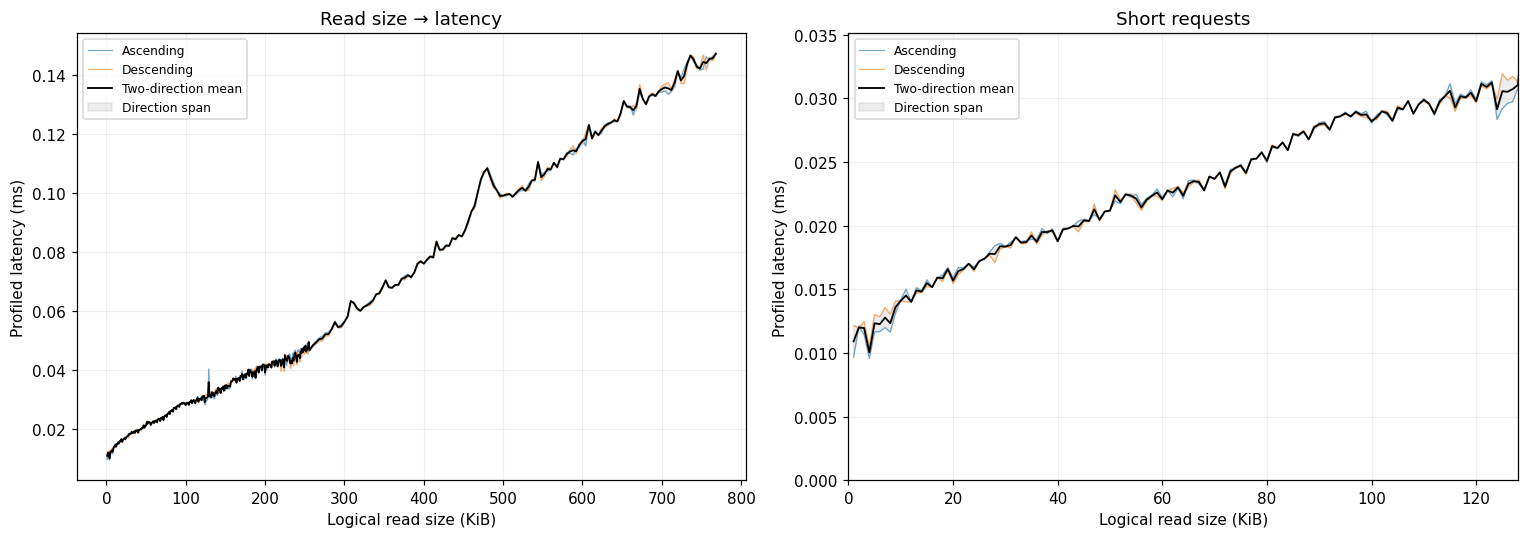

In [4]:
x = curve.index.to_numpy()
y = curve.latency_ms.to_numpy()
low = curve[["ascending_ms", "descending_ms"]].min(axis=1).to_numpy()
high = curve[["ascending_ms", "descending_ms"]].max(axis=1).to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax in axes:
    ax.plot(x, curve.ascending_ms, lw=.8, alpha=.6, label="Ascending")
    ax.plot(x, curve.descending_ms, lw=.8, alpha=.6, label="Descending")
    ax.plot(x, y, color="black", lw=1.2, label="Two-direction mean")
    ax.fill_between(x, low, high, alpha=.15, color="gray", label="Direction span")
    ax.set(xlabel="Logical read size (KiB)", ylabel="Profiled latency (ms)")
    ax.legend(fontsize=8)
axes[0].set_title("Read size → latency")
axes[1].set(xlim=(0, 128), ylim=(0, high[x <= 128].max()*1.1), title="Short requests")
figure(RUN, "size_latency")


## Latency / 크기

위 패널은 전체 범위를 로그 세로축으로 보여줍니다. 아래 패널은 큰 요청의 효율 변화를 선형 세로축으로 확대합니다.

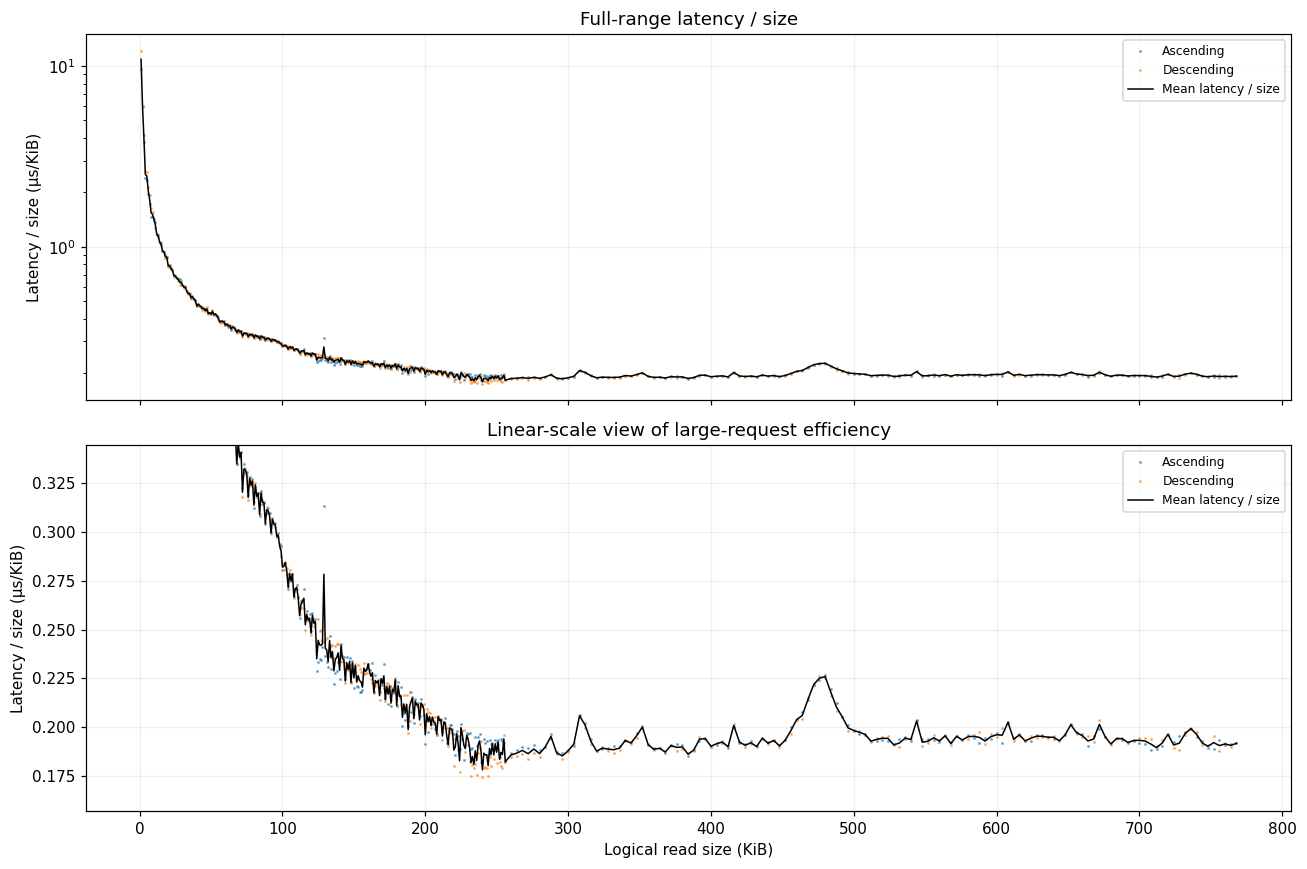

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax in axes:
    ax.plot(x, curve.ascending_ms * 1000 / x, ".", ms=2, alpha=.5, label="Ascending")
    ax.plot(x, curve.descending_ms * 1000 / x, ".", ms=2, alpha=.5, label="Descending")
    ax.plot(x, curve.latency_us_per_kib, color="black", lw=1, label="Mean latency / size")
    ax.set_ylabel("Latency / size (µs/KiB)")
    ax.legend(fontsize=8)
axes[0].set(yscale="log", title="Full-range latency / size")
zoom = np.r_[low[x >= 128] / x[x >= 128], high[x >= 128] / x[x >= 128]] * 1000
axes[1].set(ylim=(max(0, zoom.min()*.9), zoom.max()*1.1),
            xlabel="Logical read size (KiB)", title="Linear-scale view of large-request efficiency")
figure(RUN, "latency_per_size")


## 측정 순서와 배치 수의 영향

처리량이 chunk 수에 따라 안정되는지와 오름·내림 방향 차이를 함께 읽습니다.

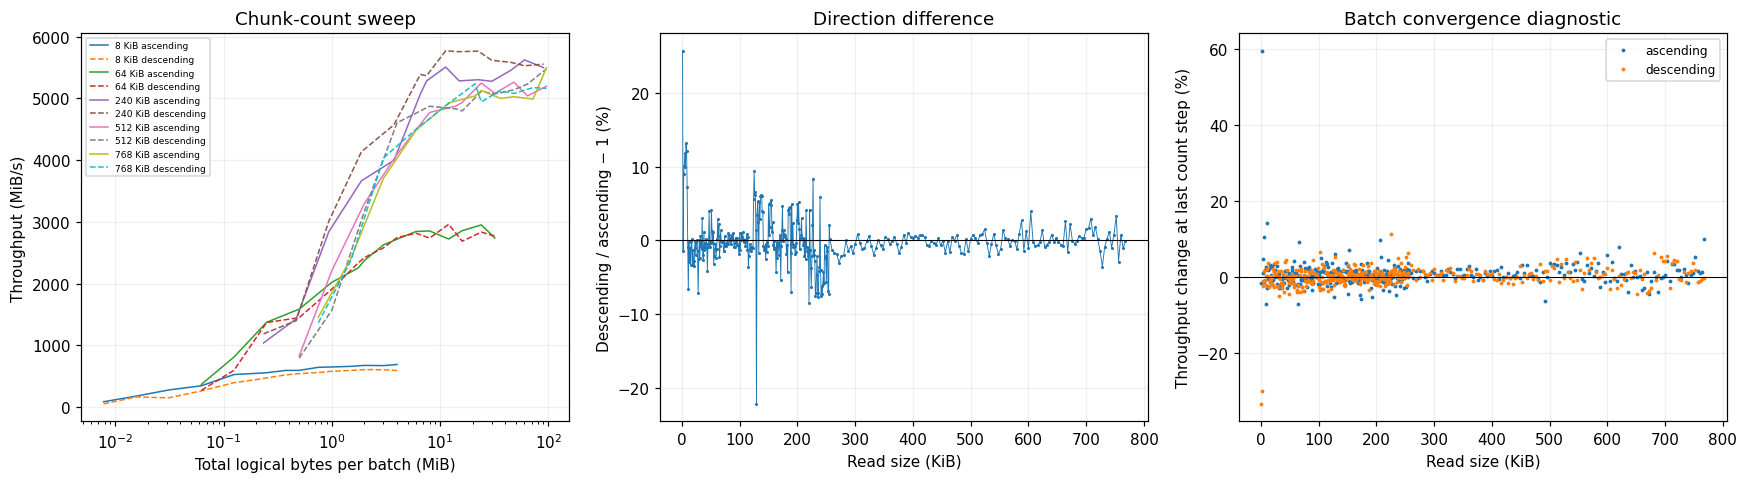

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for kib in [8, 64, 240, 512, 768]:
    for direction, style in [("ascending", "-"), ("descending", "--")]:
        group = batches[(batches.size_kib == kib) & (batches.direction == direction)]
        axes[0].plot(group.total_mib, group.throughput_mib_s, style,
                     label=f"{kib} KiB {direction}", lw=1)
axes[0].set(xscale="log", xlabel="Total logical bytes per batch (MiB)",
            ylabel="Throughput (MiB/s)", title="Chunk-count sweep")
axes[0].legend(fontsize=6)
axes[1].plot(x, curve.direction_change_pct, ".-", ms=2, lw=.6)
axes[1].axhline(0, color="black", lw=.7)
axes[1].set(xlabel="Read size (KiB)", ylabel="Descending / ascending − 1 (%)", title="Direction difference")
for direction, group in tail_check.groupby("direction"):
    axes[2].plot(group.size_kib, group.tail_change_pct, ".", ms=3, label=direction)
axes[2].axhline(0, color="black", lw=.7)
axes[2].set(xlabel="Read size (KiB)", ylabel="Throughput change at last count step (%)", title="Batch convergence diagnostic")
axes[2].legend(fontsize=8)
figure(RUN, "profiling_diagnostics")


## 측정 결과

In [4]:
finish(RUN, distinct_sizes=len(curve), size_range_kib=[int(x.min()), int(x.max())],
       raw_samples=len(raw), reader_threads=THREADS,
       median_abs_direction_change_pct=float(curve.direction_change_pct.abs().median()),
       median_abs_batch_tail_change_pct=float(tail_check.tail_change_pct.abs().median()),
       method="Submodule native profiler; size / estimated batch-throughput; ascending and descending",
       scope="Logical read sizes 1–768 KiB; direction span is not a confidence interval")


**실행에서 확인한 값**

- **distinct_sizes**: 384

- **size_range_kib**: [1, 768]

- **raw_samples**: 107660

- **reader_threads**: 6

- **median_abs_direction_change_pct**: 1.021336712758586

- **median_abs_batch_tail_change_pct**: 1.249360369825947

- **method**: Submodule native profiler; size / estimated batch-throughput; ascending and descending

- **scope**: Logical read sizes 1–768 KiB; direction span is not a confidence interval